# Two-Sample Sliced Wasserstein: Full Batch vs Mini Batch vs Pooled

When both distributions must be sampled (e.g., matching encoder outputs to a target), we compute the sliced W1/W2 between two empirical distributions X ~ P and Y ~ Q.

**Methods compared:**
- Full batch: W1(X_all, Y_all) with gradient through all samples
- Mini batch: W1(X_mini, Y_mini) — high finite-sample bias
- Standard grad accum: average T independent W1(X_i, Y_i) — does NOT reduce bias
- Pooled (2-step): T-1 no-grad passes collect X and Y samples, 1 grad pass, sort pooled — DOES reduce bias

In [1]:
import sys, os, math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
from src.accumulated_w1.losses import _random_unit_directions, _gaussian_quantiles
from src.accumulated_w1 import DeepMLP, generate_data, make_fixed_projection

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Two-Sample Sliced W1/W2 Loss

In [2]:
def sliced_w1_two_sample(x, y, num_proj=1024):
    """Sliced W1 between two empirical distributions.
    
    Args:
        x: (n, D) samples from P
        y: (m, D) samples from Q  (n and m can differ)
    Returns:
        Scalar W1 loss.
    """
    D = x.shape[-1]
    A = _random_unit_directions(D, num_proj, x.device, x.dtype)
    px = torch.sort(x @ A, dim=0).values  # (n, num_proj)
    py = torch.sort(y @ A, dim=0).values  # (m, num_proj)
    
    n, m = px.shape[0], py.shape[0]
    if n == m:
        return (px - py).abs().mean()
    else:
        # Interpolate to common grid for unequal sizes
        k = max(n, m)
        grid = torch.linspace(0, 1, k, device=x.device)
        idx_x = (grid * (n - 1)).long().clamp(0, n - 1)
        idx_y = (grid * (m - 1)).long().clamp(0, m - 1)
        return (px[idx_x] - py[idx_y]).abs().mean()


def sliced_w2_two_sample(x, y, num_proj=1024):
    """Sliced W2 between two empirical distributions."""
    D = x.shape[-1]
    A = _random_unit_directions(D, num_proj, x.device, x.dtype)
    px = torch.sort(x @ A, dim=0).values
    py = torch.sort(y @ A, dim=0).values
    
    n, m = px.shape[0], py.shape[0]
    if n == m:
        return ((px - py) ** 2).mean(-2).sqrt().mean()
    else:
        k = max(n, m)
        grid = torch.linspace(0, 1, k, device=x.device)
        idx_x = (grid * (n - 1)).long().clamp(0, n - 1)
        idx_y = (grid * (m - 1)).long().clamp(0, m - 1)
        return ((px[idx_x] - py[idx_y]) ** 2).mean(-2).sqrt().mean()

## Setup: Learn to map P → Q

Source distribution P (e.g., blobs) → MLP → output distribution.
Target distribution Q (e.g., N(0, I)).

Both P and Q are sampled — we draw fresh batches of Y ~ Q each step.

In [15]:
# Config
D = 32           # dimensionality
K = 1024        # source dataset size
M = 64          # projection dim
BS = 256          # mini-batch size
NUM_PROJ = 512  # slicing directions
STEPS = 20000
EVAL = 100
LR = 1e-3
seed = 42
loss_type = 'w1'  # 'w1' or 'w2'

loss_fn = sliced_w1_two_sample if loss_type == 'w1' else sliced_w2_two_sample

def setup(seed):
    torch.manual_seed(seed)
    data = generate_data('spiral', K, D)
    W = make_fixed_projection(D, M, seed=seed + 100).to(device)
    projected = data.to(device) @ W
    torch.manual_seed(seed + 200)
    mlp = DeepMLP(M, 128, D, depth=2).to(device)
    opt = torch.optim.Adam(mlp.parameters(), lr=LR)
    return projected, mlp, opt

def eval_w1_full(mlp, projected):
    """Eval: W1 between MLP output (all K points) and N(0,I) samples."""
    mlp.eval()
    with torch.no_grad():
        x = mlp(projected)
        y = torch.randn(K, D, device=device)
        return sliced_w1_two_sample(x, y, num_proj=1024).item()

print(f'Config: D={D}, K={K}, BS={BS}, M={M}, loss={loss_type}')

Config: D=32, K=1024, BS=256, M=64, loss=w1


## 1. Full Batch

In [16]:
projected, mlp, opt = setup(seed)
history_full = []

for step in range(1, STEPS + 1):
    mlp.train()
    x = mlp(projected)                    # all K source points
    y = torch.randn(K, D, device=device)  # fresh K target samples
    loss = loss_fn(x, y, NUM_PROJ)
    opt.zero_grad(); loss.backward(); opt.step()
    
    if step % EVAL == 0:
        w1 = eval_w1_full(mlp, projected)
        history_full.append((step, w1))
        print(f'  step={step:5d}  W1={w1:.4f}')

print(f'Full batch final: W1={history_full[-1][1]:.4f}')

  step=  100  W1=0.2529
  step=  200  W1=0.2263
  step=  300  W1=0.2117
  step=  400  W1=0.1940
  step=  500  W1=0.1828
  step=  600  W1=0.1779
  step=  700  W1=0.1662
  step=  800  W1=0.1599
  step=  900  W1=0.1626
  step= 1000  W1=0.1574
  step= 1100  W1=0.1520
  step= 1200  W1=0.1463
  step= 1300  W1=0.1446
  step= 1400  W1=0.1385
  step= 1500  W1=0.1349
  step= 1600  W1=0.1367
  step= 1700  W1=0.1326
  step= 1800  W1=0.1314
  step= 1900  W1=0.1306
  step= 2000  W1=0.1250
  step= 2100  W1=0.1238
  step= 2200  W1=0.1231
  step= 2300  W1=0.1254
  step= 2400  W1=0.1207
  step= 2500  W1=0.1221
  step= 2600  W1=0.1177
  step= 2700  W1=0.1140
  step= 2800  W1=0.1143
  step= 2900  W1=0.1137
  step= 3000  W1=0.1126
  step= 3100  W1=0.1083
  step= 3200  W1=0.1134
  step= 3300  W1=0.1108
  step= 3400  W1=0.1061
  step= 3500  W1=0.1096
  step= 3600  W1=0.1092
  step= 3700  W1=0.1067
  step= 3800  W1=0.1096
  step= 3900  W1=0.1045
  step= 4000  W1=0.1032
  step= 4100  W1=0.1054
  step= 4200  W1

## 2. Mini Batch

In [17]:
projected, mlp, opt = setup(seed)
history_mini = []

for step in range(1, STEPS + 1):
    mlp.train()
    idx = torch.randint(0, K, (BS,), device=device)
    x = mlp(projected[idx])               # BS source points
    y = torch.randn(BS, D, device=device)  # BS target samples
    loss = loss_fn(x, y, NUM_PROJ)
    opt.zero_grad(); loss.backward(); opt.step()
    
    if step % EVAL == 0:
        w1 = eval_w1_full(mlp, projected)
        history_mini.append((step, w1))
        print(f'  step={step:5d}  W1={w1:.4f}')

print(f'Mini batch final: W1={history_mini[-1][1]:.4f}')

  step=  100  W1=0.2597
  step=  200  W1=0.2422
  step=  300  W1=0.2338
  step=  400  W1=0.2263
  step=  500  W1=0.2044
  step=  600  W1=0.2008
  step=  700  W1=0.1962
  step=  800  W1=0.1915
  step=  900  W1=0.1892
  step= 1000  W1=0.1840
  step= 1100  W1=0.1889
  step= 1200  W1=0.1768
  step= 1300  W1=0.1681
  step= 1400  W1=0.1692
  step= 1500  W1=0.1607
  step= 1600  W1=0.1594
  step= 1700  W1=0.1627
  step= 1800  W1=0.1548
  step= 1900  W1=0.1618
  step= 2000  W1=0.1596
  step= 2100  W1=0.1561
  step= 2200  W1=0.1533
  step= 2300  W1=0.1497
  step= 2400  W1=0.1494
  step= 2500  W1=0.1468
  step= 2600  W1=0.1445
  step= 2700  W1=0.1466
  step= 2800  W1=0.1431
  step= 2900  W1=0.1451
  step= 3000  W1=0.1450
  step= 3100  W1=0.1437
  step= 3200  W1=0.1365
  step= 3300  W1=0.1481
  step= 3400  W1=0.1343
  step= 3500  W1=0.1361
  step= 3600  W1=0.1362
  step= 3700  W1=0.1367
  step= 3800  W1=0.1322
  step= 3900  W1=0.1366
  step= 4000  W1=0.1348
  step= 4100  W1=0.1353
  step= 4200  W1

## 3. Pooled / Two-Step

Accumulate T-1 no-grad batches of (X, Y) pairs, then 1 grad batch.
Pool all X samples together and all Y samples together before sorting.

In [18]:
T = 8
projected, mlp, opt = setup(seed)
history_pooled = []

for step in range(1, STEPS + 1):
    mlp.train()
    
    # Phase 1: T-1 no-grad forward passes — collect (X, Y) pairs
    x_detached = []
    y_detached = []
    with torch.no_grad():
        for _ in range(T - 1):
            idx = torch.randint(0, K, (BS,), device=device)
            x_detached.append(mlp(projected[idx]).detach())
            y_detached.append(torch.randn(BS, D, device=device))
    
    # Phase 2: 1 grad forward pass
    idx = torch.randint(0, K, (BS,), device=device)
    x_live = mlp(projected[idx])
    y_live = torch.randn(BS, D, device=device)
    
    # Pool all X and all Y
    x_all = torch.cat([x_live] + x_detached, dim=0)  # (T*BS, D)
    y_all = torch.cat([y_live] + y_detached, dim=0)   # (T*BS, D)
    
    # Compute two-sample W1 on pooled sets
    loss = loss_fn(x_all, y_all, NUM_PROJ)
    # Gradient dilution compensation: only BS out of T*BS x-samples have grad
    loss = loss * T
    
    opt.zero_grad(); loss.backward(); opt.step()
    
    if step % EVAL == 0:
        w1 = eval_w1_full(mlp, projected)
        history_pooled.append((step, w1))
        print(f'  step={step:5d}  W1={w1:.4f}')

print(f'Pooled (T={T}) final: W1={history_pooled[-1][1]:.4f}')

  step=  100  W1=0.2588
  step=  200  W1=0.2251
  step=  300  W1=0.2262
  step=  400  W1=0.2055
  step=  500  W1=0.1879
  step=  600  W1=0.1784
  step=  700  W1=0.1688
  step=  800  W1=0.1645
  step=  900  W1=0.1602
  step= 1000  W1=0.1519
  step= 1100  W1=0.1496
  step= 1200  W1=0.1477
  step= 1300  W1=0.1468
  step= 1400  W1=0.1435
  step= 1500  W1=0.1392
  step= 1600  W1=0.1430
  step= 1700  W1=0.1330
  step= 1800  W1=0.1353
  step= 1900  W1=0.1330
  step= 2000  W1=0.1309
  step= 2100  W1=0.1305
  step= 2200  W1=0.1308
  step= 2300  W1=0.1286
  step= 2400  W1=0.1244
  step= 2500  W1=0.1243
  step= 2600  W1=0.1240
  step= 2700  W1=0.1192
  step= 2800  W1=0.1238
  step= 2900  W1=0.1225
  step= 3000  W1=0.1177
  step= 3100  W1=0.1195
  step= 3200  W1=0.1185
  step= 3300  W1=0.1183
  step= 3400  W1=0.1161
  step= 3500  W1=0.1153
  step= 3600  W1=0.1158
  step= 3700  W1=0.1109
  step= 3800  W1=0.1104
  step= 3900  W1=0.1111
  step= 4000  W1=0.1091
  step= 4100  W1=0.1100
  step= 4200  W1

## Plot Results

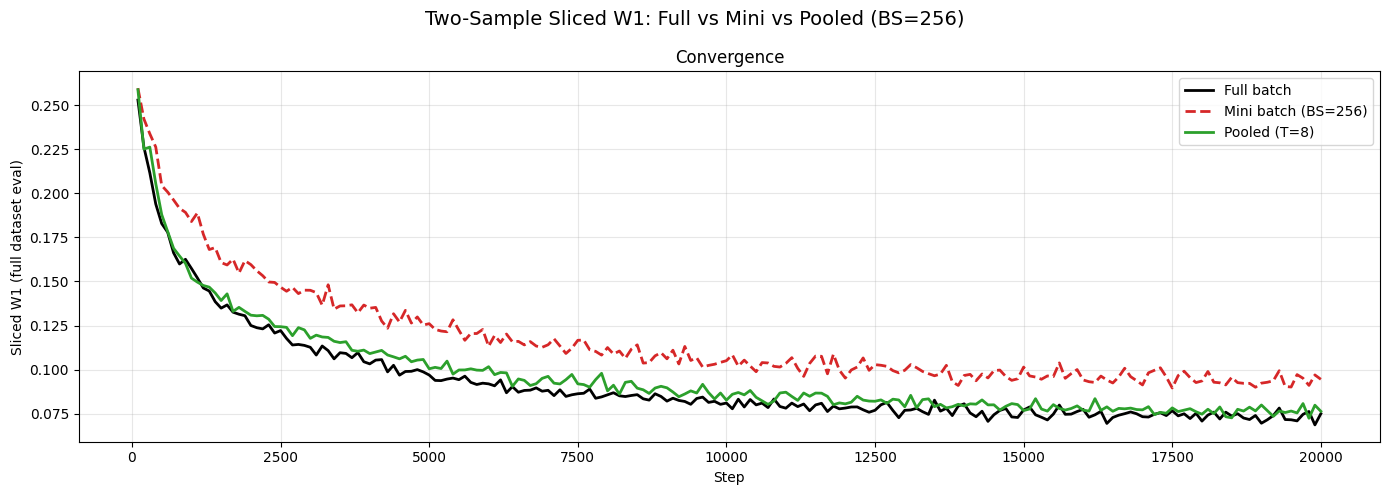

In [19]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Left: convergence curves
ax = axes
for label, hist, color, ls in [
    ('Full batch', history_full, 'black', '-'),
    (f'Mini batch (BS={BS})', history_mini, 'tab:red', '--'),
    (f'Pooled (T=8)', history_pooled, 'tab:green', '-'),
]:
    steps, vals = zip(*hist)
    ax.plot(steps, vals, label=label, color=color, linestyle=ls, linewidth=2)
ax.set_xlabel('Step')
ax.set_ylabel(f'Sliced {loss_type.upper()} (full dataset eval)')
ax.set_title('Convergence')
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle(f'Two-Sample Sliced {loss_type.upper()}: Full vs Mini vs Pooled (BS={BS})', fontsize=14)
fig.tight_layout()
plt.show()